🚀 Top 10 Active Dimensions for emb_cube_103.npz:
   1. Dim 117 (Variance: 1.8237)
   2. Dim 392 (Variance: 1.1628)
   3. Dim 61 (Variance: 1.1348)
   4. Dim 346 (Variance: 0.5522)
   5. Dim 873 (Variance: 0.3905)
   6. Dim 657 (Variance: 0.3388)
   7. Dim 640 (Variance: 0.3246)
   8. Dim 913 (Variance: 0.2856)
   9. Dim 405 (Variance: 0.2815)
   10. Dim 66 (Variance: 0.2670)

✅ Saved visualization to: top_dimensions/top_dims_emb_cube_103.png


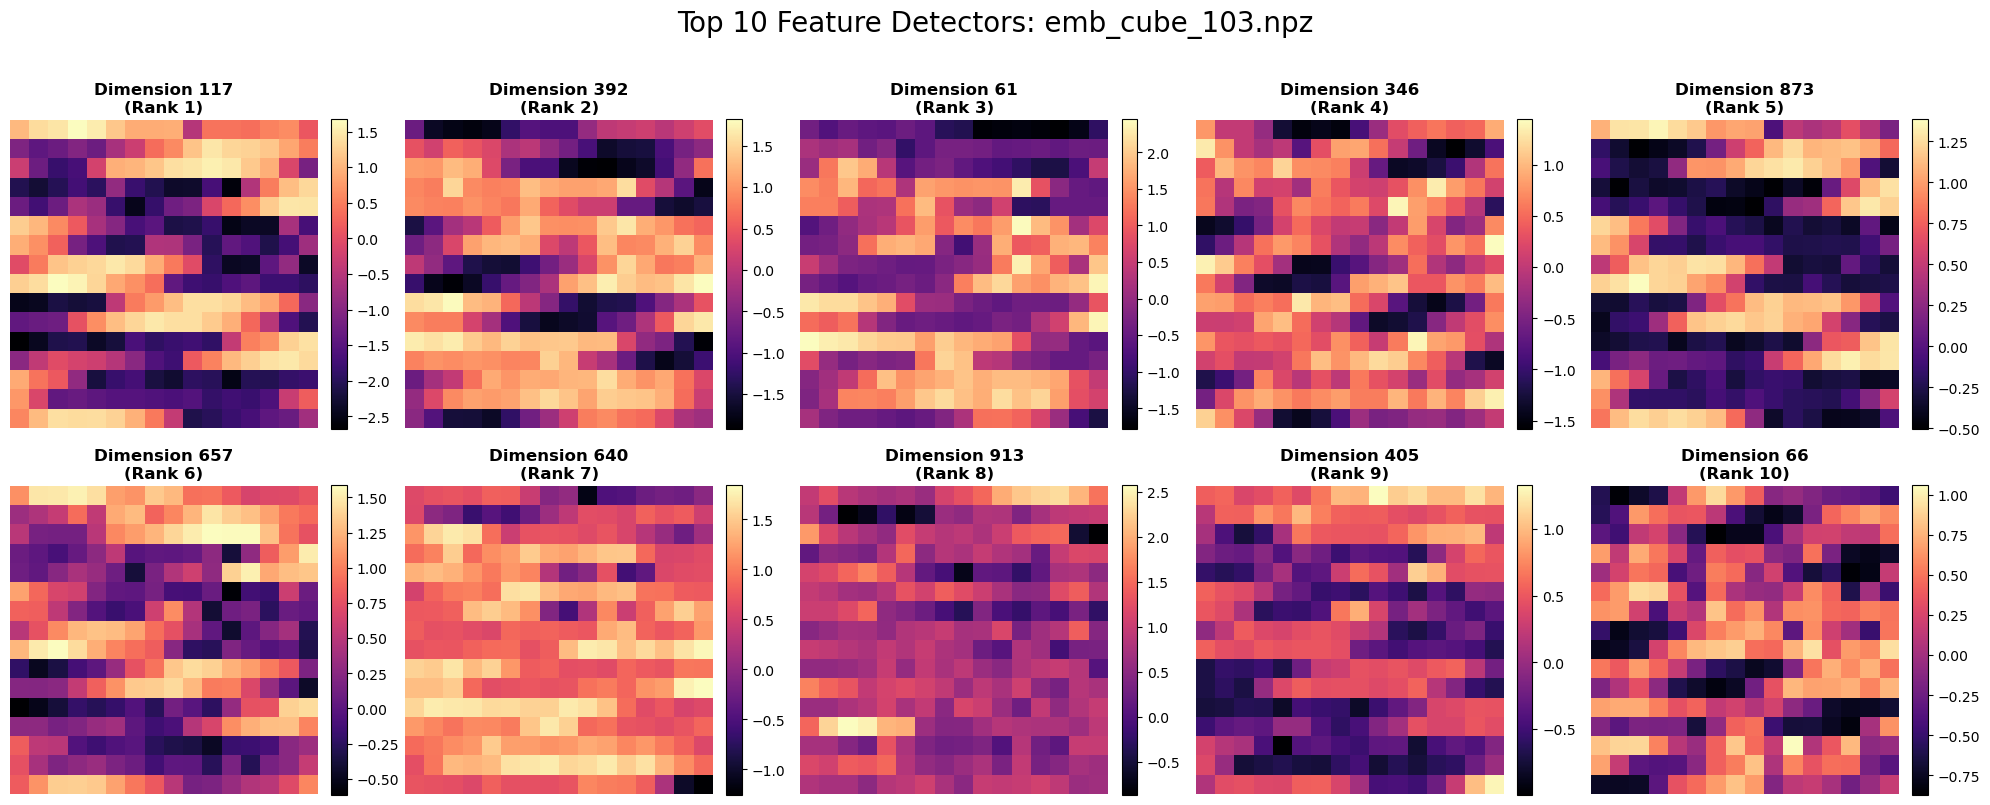

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# CONFIG
# ==========================================
EMBED_PATH = Path('../../data/embeddings/2005/emb_cube_103.npz') # Change to a file you have
SAVE_DIR = Path('./top_dimensions/')
SAVE_DIR.mkdir(exist_ok=True)

GRID_H, GRID_W = 16, 16

# ==========================================
# 1. LOAD AND CALCULATE ACTIVITY
# ==========================================
with np.load(EMBED_PATH) as data:
    # Get the spatial embeddings (ignoring [CLS] token at index 0)
    # Shape: (256, 1024)
    embeds = data['embedding'] if 'embedding' in data else data['embeddings']
    spatial_data = embeds[1:, :] 

# Activity Filter: Calculate Variance for each of the 1024 dimensions
# This tells us which dimensions are actually "reacting" to features in this tile
variances = np.var(spatial_data, axis=0)

# Get indices of the top 10 highest variance dimensions
top_10_indices = np.argsort(variances)[-10:][::-1]

print(f"🚀 Top 10 Active Dimensions for {EMBED_PATH.name}:")
for i, idx in enumerate(top_10_indices):
    print(f"   {i+1}. Dim {idx} (Variance: {variances[idx]:.4f})")

# ==========================================
# 2. VISUALIZE TOP 10
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, dim_idx in enumerate(top_10_indices):
    # Reshape the 256 vector into 16x16 grid
    heatmap = spatial_data[:, dim_idx].reshape(GRID_H, GRID_W)
    
    im = axes[i].imshow(heatmap, cmap='magma')
    axes[i].set_title(f"Dimension {dim_idx}\n(Rank {i+1})", fontsize=12, fontweight='bold')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle(f"Top 10 Feature Detectors: {EMBED_PATH.name}", fontsize=20, y=1.02)
plt.tight_layout()

# Save the discovery
save_path = SAVE_DIR / f"top_dims_{EMBED_PATH.stem}.png"
plt.savefig(save_path, bbox_inches='tight')
print(f"\n✅ Saved visualization to: {save_path}")
plt.show()

🎯 Selected 8 tiles to track across time.


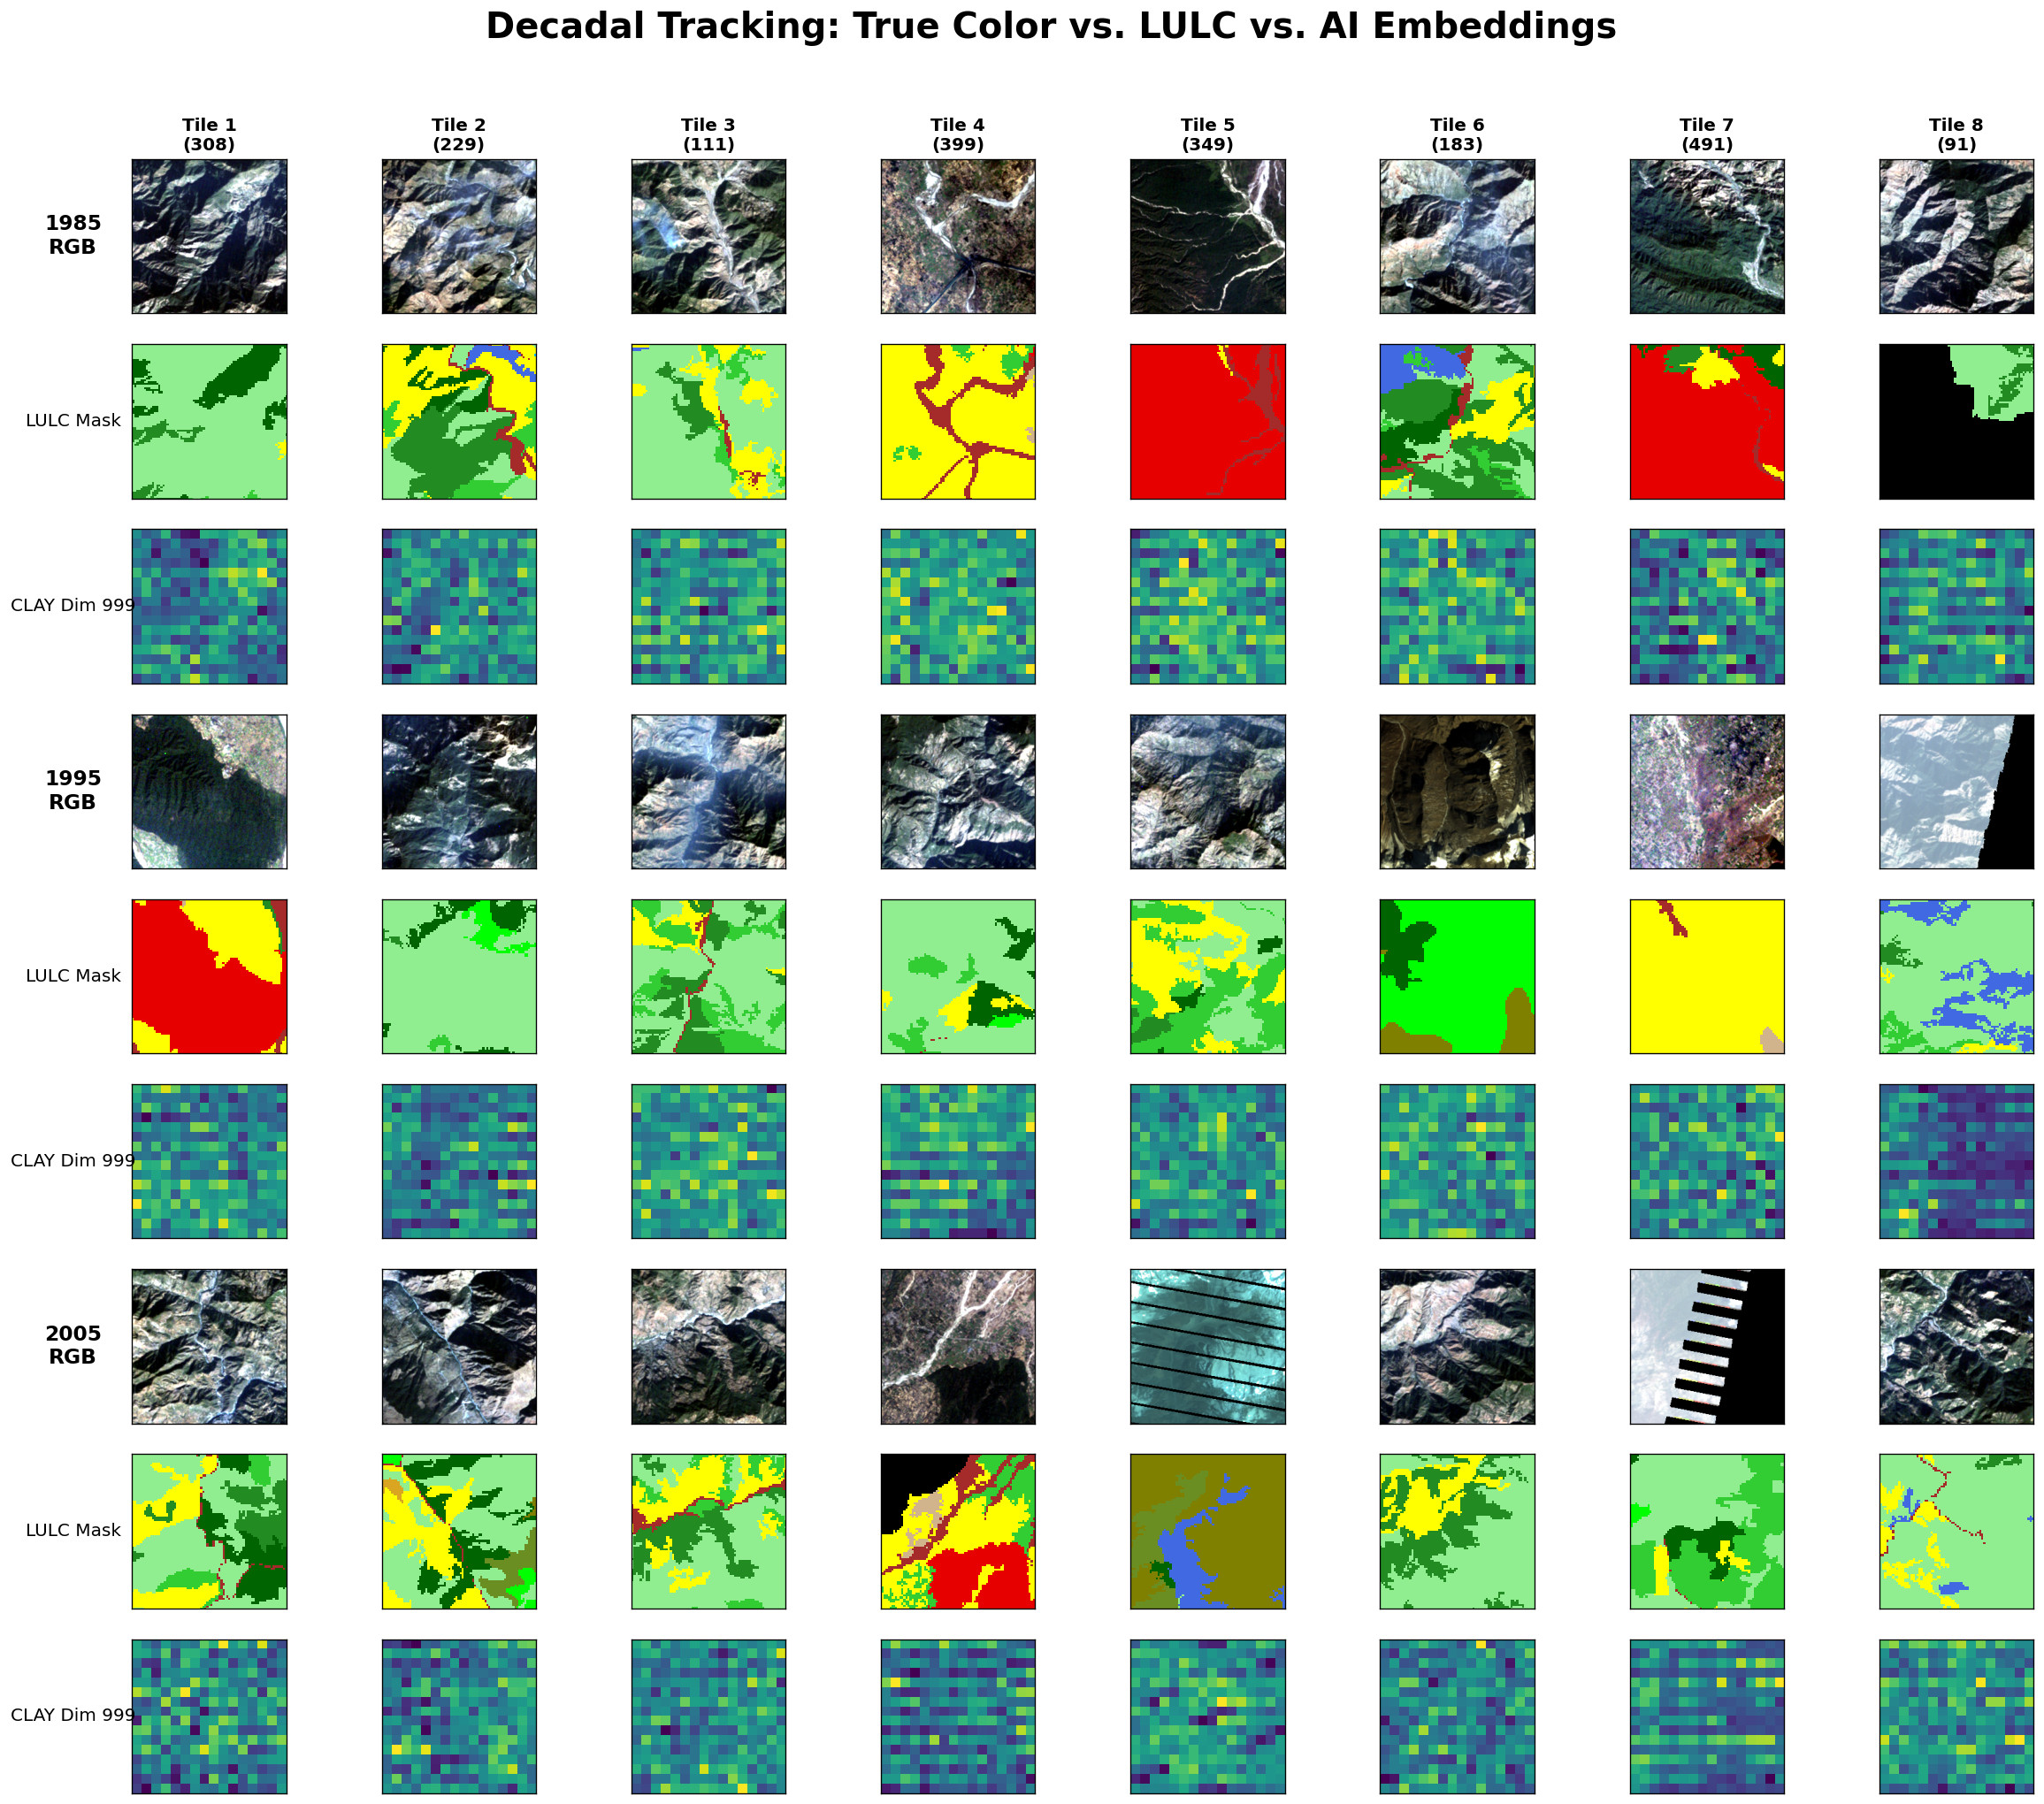

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

# ==========================================
# 1. SETUP & PATHS
# ==========================================
sys.path.append('..')
try:
    from lulc_classes import LULC_CLASS_MAP, class_colors
    cmap = ListedColormap(class_colors)
    norm = BoundaryNorm(np.arange(-0.5, 20.5, 1), cmap.N)
except ImportError:
    print("❌ ERROR: Could not find 'lulc_classes.py'.")
    sys.exit(1)

YEARS = ['1985', '1995', '2005']
DATA_DIR = Path('../../data/dataset/')
EMBED_DIR = Path('../../data/embeddings/')

EMBED_DIM = 999
GRID_H, GRID_W = 16, 16

# ==========================================
# 2. FIND 8 COMMON TILES ACROSS ALL DECADES
# ==========================================
common_filenames = None
for year in YEARS:
    files_in_year = set([f.name for f in (EMBED_DIR / year).glob('emb_cube_*.npz')])
    if common_filenames is None:
        common_filenames = files_in_year
    else:
        common_filenames = common_filenames.intersection(files_in_year)

if not common_filenames:
    raise ValueError("Could not find any 'emb_cube_*.npz' files that exist in all year folders.")

# Sample 8 random tiles (or however many are available if < 8)
num_cols = min(8, len(common_filenames))
sample_files = random.sample(list(common_filenames), num_cols)

print(f"🎯 Selected {num_cols} tiles to track across time.")

# ==========================================
# 3. VISUALIZATION UTILS
# ==========================================
def robust_stretch(img):
    """Enhances RGB imagery for plotting."""
    low, high = np.nanpercentile(img, (2, 98))
    return np.clip((img - low) / (high - low), 0, 1) if high > low else img

# ==========================================
# 4. PLOT THE 9x8 GRID
# ==========================================
# 9 Rows (3 years * 3 data types) x 8 Columns
fig, axs = plt.subplots(9, num_cols, figsize=(3 * num_cols, 20), dpi=120)
plt.subplots_adjust(hspace=0.2, wspace=0.1)

# Loop over the 3 decades
for y_idx, year in enumerate(YEARS):
    # Loop over the 8 columns (tiles)
    for j, target_filename in enumerate(sample_files):
        
        # File paths
        raw_path = DATA_DIR / year / target_filename.replace('emb_', '')
        emb_path = EMBED_DIR / year / target_filename
        
        # --- LOAD DATA ---
        with np.load(raw_path) as raw_data:
            image = raw_data['image'] if 'image' in raw_data else raw_data['pixels']
            
        with np.load(emb_path) as emb_data:
            embeds = emb_data['embedding'] if 'embedding' in emb_data else emb_data['embeddings']
            mask = emb_data['mask']
            
        # --- PROCESS DATA ---
        rgb_img = np.dstack([robust_stretch(image[i]) for i in [0, 1, 2]])
        spatial_embeds = embeds[1:, :].reshape(GRID_H, GRID_W, -1)
        single_dim_map = spatial_embeds[:, :, EMBED_DIM]
        
        # --- DEFINE ROW INDICES FOR THIS YEAR ---
        row_rgb = y_idx * 3
        row_mask = y_idx * 3 + 1
        row_emb = y_idx * 3 + 2
        
        # --- PLOT RGB ---
        axs[row_rgb][j].imshow(rgb_img)
        axs[row_rgb][j].set_xticks([])
        axs[row_rgb][j].set_yticks([])
        
        # Add Column Headers to the very top row
        if y_idx == 0: 
            axs[row_rgb][j].set_title(f"Tile {j+1}\n({target_filename.replace('emb_cube_', '').replace('.npz', '')})", fontsize=12, fontweight='bold')
        
        # Add Row Labels to the very first column
        if j == 0: 
            axs[row_rgb][0].set_ylabel(f"{year}\nRGB", fontsize=14, fontweight='bold', rotation=0, labelpad=40, va='center')
        
        # --- PLOT MASK ---
        axs[row_mask][j].imshow(mask, cmap=cmap, norm=norm, interpolation='nearest')
        axs[row_mask][j].set_xticks([])
        axs[row_mask][j].set_yticks([])
        if j == 0: 
            axs[row_mask][0].set_ylabel(f"LULC Mask", fontsize=12, rotation=0, labelpad=40, va='center')
        
        # --- PLOT EMBEDDING ---
        axs[row_emb][j].imshow(single_dim_map, cmap="viridis")
        axs[row_emb][j].set_xticks([])
        axs[row_emb][j].set_yticks([])
        if j == 0: 
            axs[row_emb][0].set_ylabel(f"CLAY Dim {EMBED_DIM}", fontsize=12, rotation=0, labelpad=40, va='center')

plt.suptitle(f"Decadal Tracking: True Color vs. LULC vs. AI Embeddings", fontsize=24, y=0.95, fontweight='bold')
plt.show()